### Goal: Perform a regression on model 1 

In [1]:
import os, sys
import time
import csv
import tqdm.notebook as tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import curve_fit
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.decomposition import PCA
import warnings
from sklearn.metrics import r2_score
from sklearn.exceptions import ConvergenceWarning

from mgsa.io import samples_from_soils, get_function, get_data
from mgsa.modeling import Model
from mgsa.helpers import plot

### Load in data

In [2]:
NARG_INFO = {
    "KO": "K00370",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00370_v3.tsv"
}

NIRB_INFO = {
    "KO": "K00362",
    "ORF_GROUPS_FPATH": "../out/groups/assignments_K00362_v1.tsv"
}

NATIVE_IDXS = [2, 4, 5, 8, 10, 11, 13, 14, 15, 16]
NATIVE_PHS = np.array([5.0, 5.3, 5.41, 5.8, 6.15, 6.3, 6.5, 6.75, 6.9,  7.1])
PERTURBED_PHS = np.linspace(3.8, 8, 10)

OUTDIR = "../out/model_regression/nar"
IMGDIR = f"{OUTDIR}/images"
os.makedirs(OUTDIR, exist_ok=True)
os.makedirs(IMGDIR, exist_ok=True)

def texify(param_name):
    return {
        "gamma_A": "\\gamma_{{A}}", 
        "gamma_I": "\\gamma_{{I}}", 
        "r_A": "r_{{A}}", 
        "r_I1": "r_{{I1}}", 
        "r_I2": "r_{{I2}}", 
        "K_A": "K_{{A}}", 
        "K_I": "K_{{I}}", 
        "mu": "\\mu", 
    }[param_name]

t_data_drug = np.linspace(0, 19, 20)

soils = [
    'Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 
    'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17'
]



def load_orf_groups(fpath) -> tuple[dict[int:str], np.ndarray[int]]:
    groups = {}
    idxs = []
    with open(fpath, "r") as f:
        csvreader = csv.reader(f, delimiter=" ")
        for row in csvreader:  # process each row
            orf = row[0]
            gidx = int(row[1])
            if gidx in groups:
                groups[gidx].append(orf)
            else:
                groups[gidx] = [orf]
                idxs.append(gidx)
    return groups, np.sort(idxs)

##############################################################################
##  Collect narG data

# Load ORF groups for narG
groups, group_idxs = load_orf_groups(NARG_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}
for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NARG_INFO["KO"], 
            drug='None', 
            map='09',
        )
        
        data_chl_pos_t9 = [row[:10] for row in data_chl_pos_t9]
        data_chl_neg_t9 = [row[:10] for row in data_chl_neg_t9]
        
        # Subset T0 samples to those of interest
        data_chl_pos_t0 = data_chl_pos_t0[NATIVE_IDXS]
        data_chl_neg_t0 = data_chl_neg_t0[NATIVE_IDXS]

        gidx2exp_chl_pos_t0[gidx].append(data_chl_pos_t0)
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t0[gidx].append(data_chl_neg_t0)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t0[gidx] = np.sum(gidx2exp_chl_pos_t0[gidx], axis=0)
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t0[gidx] = np.sum(gidx2exp_chl_neg_t0[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t0[gidx].shape == (10,), "Wrong shape for t0 pos"
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,10), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t0[gidx].shape == (10,), "Wrong shape for t0 neg"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,10), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nar_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_pos_t9 = np.zeros([10, 10, len(group_idxs)])
nar_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nar_exp_chl_neg_t9 = np.zeros([10, 10, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nar_exp_chl_pos_t0[...,i] = gidx2exp_chl_pos_t0[gidx]
    nar_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nar_exp_chl_neg_t0[...,i] = gidx2exp_chl_neg_t0[gidx]
    nar_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]

##############################################################################
##  Collect nirB data

# Load ORF groups for nirB
groups, group_idxs = load_orf_groups(NIRB_INFO["ORF_GROUPS_FPATH"])
total = 0
for gidx in group_idxs:
    group = groups[gidx]
    n = len(group)
    print(f"Group {gidx}: {n} ORFs")
    total += n
print(f"  Total: {total}")

# Aggregate T0 and T9 expression data in the CHL+ and CHL- conditions
gidx2exp_chl_pos_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_pos_t9 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t0 = {gidx: [] for gidx in group_idxs}
gidx2exp_chl_neg_t9 = {gidx: [] for gidx in group_idxs}
for gidx in group_idxs:
    group = groups[gidx]
    for i, orf in enumerate(group):
        data_chl_pos_t0, data_chl_pos_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='CHL', 
            map='09',
        )
        data_chl_neg_t0, data_chl_neg_t9 = get_data(
            orf, 
            DATDIR='../out', 
            KO=NIRB_INFO["KO"], 
            drug='None', 
            map='09',
        )
        
        data_chl_pos_t9 = [row[:10] for row in data_chl_pos_t9]
        data_chl_neg_t9 = [row[:10] for row in data_chl_neg_t9]
        # Subset T0 samples to those of interest
        data_chl_pos_t0 = data_chl_pos_t0[NATIVE_IDXS]
        data_chl_neg_t0 = data_chl_neg_t0[NATIVE_IDXS]

        gidx2exp_chl_pos_t0[gidx].append(data_chl_pos_t0)
        gidx2exp_chl_pos_t9[gidx].append(data_chl_pos_t9)
        gidx2exp_chl_neg_t0[gidx].append(data_chl_neg_t0)
        gidx2exp_chl_neg_t9[gidx].append(data_chl_neg_t9)

    # Sum the expression data in each group
    gidx2exp_chl_pos_t0[gidx] = np.sum(gidx2exp_chl_pos_t0[gidx], axis=0)
    gidx2exp_chl_pos_t9[gidx] = np.sum(gidx2exp_chl_pos_t9[gidx], axis=0)
    gidx2exp_chl_neg_t0[gidx] = np.sum(gidx2exp_chl_neg_t0[gidx], axis=0)
    gidx2exp_chl_neg_t9[gidx] = np.sum(gidx2exp_chl_neg_t9[gidx], axis=0)

# Check lengths are correct
for gidx in group_idxs:
    assert gidx2exp_chl_pos_t0[gidx].shape == (10,), "Wrong shape for t0 pos"
    assert gidx2exp_chl_pos_t9[gidx].shape == (10,10), "Wrong shape for t9 pos"
    assert gidx2exp_chl_neg_t0[gidx].shape == (10,), "Wrong shape for t0 neg"
    assert gidx2exp_chl_neg_t9[gidx].shape == (10,10), "Wrong shape for t9 neg"

# Construct arrays of aggregated soil expression levels. The last axis 
# corresponds to the groups.
nir_exp_chl_pos_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_pos_t9 = np.zeros([10, 10, len(group_idxs)])
nir_exp_chl_neg_t0 = np.zeros([10, len(group_idxs)])
nir_exp_chl_neg_t9 = np.zeros([10, 10, len(group_idxs)])
for i, gidx in enumerate(group_idxs):
    nir_exp_chl_pos_t0[...,i] = gidx2exp_chl_pos_t0[gidx]
    nir_exp_chl_pos_t9[...,i] = gidx2exp_chl_pos_t9[gidx]
    nir_exp_chl_neg_t0[...,i] = gidx2exp_chl_neg_t0[gidx]
    nir_exp_chl_neg_t9[...,i] = gidx2exp_chl_neg_t9[gidx]




Group 1: 14 ORFs
Group 2: 4 ORFs
Group 3: 4 ORFs
Group 4: 8 ORFs
Group 5: 6 ORFs
Group 6: 6 ORFs
Group 7: 5 ORFs
Group 8: 10 ORFs
  Total: 57
Group 1: 24 ORFs
Group 2: 15 ORFs
Group 3: 10 ORFs
Group 4: 13 ORFs
  Total: 62


## `X' Regression Options

### Include T0

In [25]:
##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_pos_t0 = nar_exp_chl_pos_t0 / np.sum(nar_exp_chl_pos_t0, -1)[...,None]
nar_rel_exp_chl_pos_t0 = nar_rel_exp_chl_pos_t0[:, np.newaxis, :]
nar_rel_exp_chl_pos_t0 = np.broadcast_to(nar_rel_exp_chl_pos_t0, (10, 10, 8))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t0 = nir_exp_chl_pos_t0 / np.sum(nir_exp_chl_pos_t0, -1)[...,None]
nir_rel_exp_chl_pos_t0 = nir_rel_exp_chl_pos_t0[:, np.newaxis, :]
nir_rel_exp_chl_pos_t0 = np.broadcast_to(nir_rel_exp_chl_pos_t0, (10, 10, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_pos_t9 = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t9 = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_neg_t0 = nar_exp_chl_neg_t0 / np.sum(nar_exp_chl_neg_t0, -1)[...,None]
nar_rel_exp_chl_neg_t0 = nar_rel_exp_chl_neg_t0[:, np.newaxis, :]
nar_rel_exp_chl_neg_t0 = np.broadcast_to(nar_rel_exp_chl_neg_t0, (10, 10, 8))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t0 = nir_exp_chl_neg_t0 / np.sum(nir_exp_chl_neg_t0, -1)[...,None]
nir_rel_exp_chl_neg_t0 = nir_rel_exp_chl_neg_t0[:, np.newaxis, :]
nir_rel_exp_chl_neg_t0 = np.broadcast_to(nir_rel_exp_chl_neg_t0, (10, 10, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_neg_t9 = nar_exp_chl_neg_t9 / np.sum(nar_exp_chl_neg_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t9 = nir_exp_chl_neg_t9 / np.sum(nir_exp_chl_neg_t9, -1)[...,None]

X_NAR_CHL_POS = np.concatenate([nar_rel_exp_chl_pos_t0, nar_rel_exp_chl_pos_t9], axis = -1)
X_NIR_CHL_POS = np.concatenate([nir_rel_exp_chl_pos_t0, nir_rel_exp_chl_pos_t9], axis = -1)
X_NAR_CHL_NEG = np.concatenate([nar_rel_exp_chl_neg_t0, nar_rel_exp_chl_neg_t9], axis = -1)
X_NIR_CHL_NEG = np.concatenate([nir_rel_exp_chl_neg_t0, nir_rel_exp_chl_neg_t9], axis = -1)

### Average of T0 and T9 CHL+

In [27]:
##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_pos_t0 = nar_exp_chl_pos_t0 / np.sum(nar_exp_chl_pos_t0, -1)[...,None]
nar_rel_exp_chl_pos_t0 = nar_rel_exp_chl_pos_t0[:, np.newaxis, :]
nar_rel_exp_chl_pos_t0 = np.broadcast_to(nar_rel_exp_chl_pos_t0, (10, 10, 8))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t0 = nir_exp_chl_pos_t0 / np.sum(nir_exp_chl_pos_t0, -1)[...,None]
nir_rel_exp_chl_pos_t0 = nir_rel_exp_chl_pos_t0[:, np.newaxis, :]
nir_rel_exp_chl_pos_t0 = np.broadcast_to(nir_rel_exp_chl_pos_t0, (10, 10, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_pos_t9 = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t9 = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize narG expression levels
nar_rel_exp_chl_neg_t0 = nar_exp_chl_neg_t0 / np.sum(nar_exp_chl_neg_t0, -1)[...,None]
nar_rel_exp_chl_neg_t0 = nar_rel_exp_chl_neg_t0[:, np.newaxis, :]
nar_rel_exp_chl_neg_t0 = np.broadcast_to(nar_rel_exp_chl_neg_t0, (10, 10, 8))

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t0 = nir_exp_chl_neg_t0 / np.sum(nir_exp_chl_neg_t0, -1)[...,None]
nir_rel_exp_chl_neg_t0 = nir_rel_exp_chl_neg_t0[:, np.newaxis, :]
nir_rel_exp_chl_neg_t0 = np.broadcast_to(nir_rel_exp_chl_neg_t0, (10, 10, 4))

##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_neg_t9 = nar_exp_chl_neg_t9 / np.sum(nar_exp_chl_neg_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_neg_t9 = nir_exp_chl_neg_t9 / np.sum(nir_exp_chl_neg_t9, -1)[...,None]

X_NAR_CHL_POS = (nar_rel_exp_chl_pos_t0 + nar_rel_exp_chl_pos_t9)/2
X_NIR_CHL_POS = (nir_rel_exp_chl_pos_t0 + nir_rel_exp_chl_pos_t9)/2
X_NAR_CHL_NEG = X_NAR_CHL_POS
X_NIR_CHL_NEG = X_NIR_CHL_POS

### Only T9

In [3]:


##############################################################################
##  Normalize narG expression levels

nar_rel_exp_chl_pos_t9 = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
nir_rel_exp_chl_pos_t9 = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]



X_NAR_CHL_POS = nar_rel_exp_chl_pos_t9
X_NIR_CHL_POS = nir_rel_exp_chl_pos_t9
X_NAR_CHL_NEG = X_NAR_CHL_POS
X_NIR_CHL_NEG = X_NIR_CHL_POS

### Do not normalize expression levels

In [97]:

##############################################################################
## 

X_NAR_CHL_POS = nar_exp_chl_pos_t9 

##############################################################################
## 
X_NIR_CHL_POS = nir_exp_chl_pos_t9 


##############################################################################
##  

X_NAR_CHL_NEG = nar_exp_chl_neg_t9 

##############################################################################
##  
X_NIR_CHL_NEG = nir_exp_chl_neg_t9 


### Do normalize expression levels

In [103]:

##############################################################################
##  Normalize narG expression levels

X_NAR_CHL_POS = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

X_NAR_TOTAL = np.sum(nar_exp_chl_pos_t9, axis = 2)

##############################################################################
##  Normalize nirB expression levels
X_NIR_CHL_POS = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]


##############################################################################
##  Normalize narG expression levels

X_NAR_CHL_NEG = nar_exp_chl_neg_t9 / np.sum(nar_exp_chl_neg_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
X_NIR_CHL_NEG = nir_exp_chl_neg_t9 / np.sum(nir_exp_chl_neg_t9, -1)[...,None]




### Give both CHL+/- both sets of abundance data

In [ ]:

##############################################################################
##  Normalize narG expression levels

X_NAR_CHL_POS = nar_exp_chl_pos_t9 / np.sum(nar_exp_chl_pos_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
X_NIR_CHL_POS = nir_exp_chl_pos_t9 / np.sum(nir_exp_chl_pos_t9, -1)[...,None]


##############################################################################
##  Normalize narG expression levels

X_NAR_CHL_NEG = nar_exp_chl_neg_t9 / np.sum(nar_exp_chl_neg_t9, -1)[...,None]

##############################################################################
##  Normalize nirB expression levels
X_NIR_CHL_NEG = nir_exp_chl_neg_t9 / np.sum(nir_exp_chl_neg_t9, -1)[...,None]


##############################################################################
##  Combine

X_NAR_CHL_POS = np.concatenate([X_NAR_CHL_POS, X_NAR_CHL_NEG ], axis = -1)
X_NAR_CHL_NEG = X_NAR_CHL_POS

X_NIR_CHL_POS = np.concatenate([X_NIR_CHL_POS, X_NIR_CHL_NEG ], axis = -1)
X_NIR_CHL_NEG = X_NIR_CHL_POS

### CHL-/+ folds

In [ ]:
eps = 0.0001
##############################################################################
##  Compute folds

X_NAR_CHL_POS = nar_exp_chl_neg_t9 / (nar_exp_chl_pos_t9 + eps)

X_NAR_CHL_NEG = X_NAR_CHL_POS

##############################################################################
##  
X_NIR_CHL_POS = nir_exp_chl_neg_t9 / (nir_exp_chl_pos_t9 + eps)

X_NIR_CHL_NEG = X_NIR_CHL_POS


### Random Numbers (Null)

In [ ]:
import random
X_NAR_CHL_POS = np.zeros_like(nar_exp_chl_neg_t9)
X_NAR_CHL_NEG = X_NAR_CHL_POS

x, y, z = X_NAR_CHL_POS.shape 
for i in range(x):
    for j in range(y):
        for k in range(z):
            X_NAR_CHL_POS[i,j,k] = random.uniform(0,1)
            X_NAR_CHL_NEG[i,j,k] = random.uniform(0,1)
            
X_NIR_CHL_POS = np.zeros_like(nir_exp_chl_neg_t9)
X_NIR_CHL_NEG = X_NIR_CHL_POS

x, y, z = X_NIR_CHL_POS.shape 
for i in range(x):
    for j in range(y):
        for k in range(z):
            X_NIR_CHL_POS[i,j,k] = random.uniform(0,1)
            X_NIR_CHL_NEG[i,j,k] = random.uniform(0,1)


### Generate pH matrix

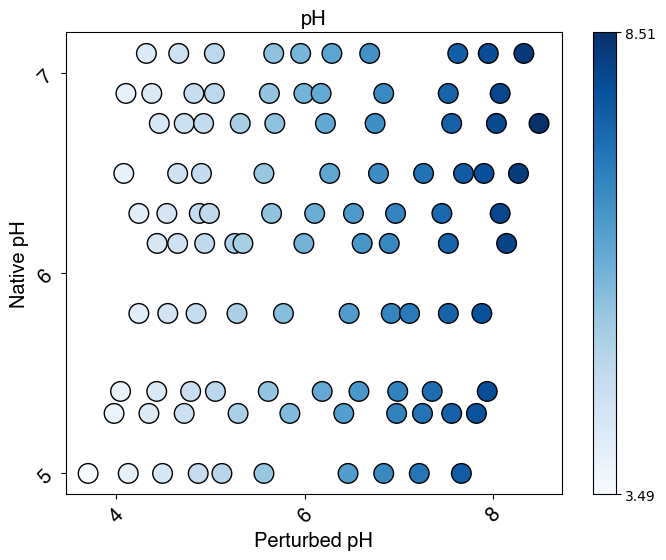

In [ ]:
from mgsa.io import pH_soil
from mgsa.helpers import plot10
soils = ['Soil3', 'Soil5', 'Soil6', 'Soil9', 'Soil11', 'Soil12', 'Soil14', 'Soil15', 'Soil16', 'Soil17']

pH_matrix = np.zeros((10,10))
for i in range(len(pH_matrix)):
    pH_matrix[i] = pH_soil(soils[i])[:10]
    
plot10(pH_matrix, 'pH')


### Regression Target: Model Parameters



In [ ]:
# rA_chl_pos = pd.read_csv('../out/metabolic_parameters/rA_model1_chl_pos.tsv', sep = '\t', header = None).values
# rA_chl_neg = pd.read_csv('../out/metabolic_parameters/rA_model1_chl_neg.tsv', sep = '\t', header = None).values
# rI_chl_pos = pd.read_csv('../out/metabolic_parameters/rI_model1_chl_pos.tsv', sep = '\t', header = None).values
# rI_chl_neg = pd.read_csv('../out/metabolic_parameters/rI_model1_chl_neg.tsv', sep = '\t', header = None).values


# Y_CHL_POS = np.concatenate([rA_chl_pos[..., np.newaxis], rI_chl_pos[..., np.newaxis]], axis = -1)
# Y_CHL_NEG = np.concatenate([rA_chl_neg[..., np.newaxis], rI_chl_neg[..., np.newaxis]], axis = -1)

### Regress on CHL+

In [53]:
# X_nar_flat = X_NAR_CHL_POS.reshape(-1, X_NAR_CHL_POS.shape[2])  # shape: (n_samples * 10, n_features)
# y_nar_flat = Y_CHL_POS[:, :, 0].flatten()                        # shape: (n_samples * 10,)

# X_nir_flat = X_NIR_CHL_POS.reshape(-1, X_NIR_CHL_POS.shape[2])
# y_nir_flat = Y_CHL_POS[:, :, 1].flatten()

# ALPHA = 0.00001

# clf_nar = Lasso(alpha=ALPHA)
# clf_nar.fit(X_nar_flat, y_nar_flat)

# clf_nir = Lasso(alpha=ALPHA)
# clf_nir.fit(X_nir_flat, y_nir_flat)

# print("NAR Coefficients:", clf_nar.coef_)
# print("NAR Intercept:", clf_nar.intercept_)

# print("NIR Coefficients:", clf_nir.coef_)
# print("NIR Intercept:", clf_nir.intercept_)

# pred_rA = clf_nar.predict(X_nar_flat)
# obs_rA = y_nar_flat

# pred_rI = clf_nir.predict(X_nir_flat)
# obs_rI = y_nir_flat

# r2_nar = r2_score(y_nar_flat, pred_rA)
# r2_nir = r2_score(y_nir_flat, pred_rI)

# nar_scale = 2     
# x = np.linspace(0,nar_scale,10)
# y = np.linspace(0,nar_scale,10)
# plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.xlabel('$r_A$ Observed')
# plt.ylabel('$r_A$ Predicted')
# plt.text(0.05, 1.8, f'$R^2$ = {r2_nar:.3f}', fontsize=12, color='black')
# plt.xlim(0, nar_scale)
# plt.ylim(0, nar_scale)
# plt.title('CHL+ LASSO prediction $r_A$')
# plt.show()

# nir_scale = 20
# x = np.linspace(0,nir_scale,10)
# y = np.linspace(0,nir_scale,10)
# plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.text(0.6, 18, f'$R^2$ = {r2_nir:.3f}', fontsize=12, color='black')
# plt.xlabel('$r_I$ Observed')
# plt.ylabel('$r_I$ Predicted')
# plt.xlim(0, nir_scale)
# plt.ylim(0, nir_scale)
# plt.title('CHL+ LASSO prediction $r_I$')
# plt.show()

### Regress on CHL-

In [52]:
# X_nar_flat = X_NAR_CHL_NEG.reshape(-1, X_NAR_CHL_NEG.shape[2])  # shape: (n_samples * 10, n_features)
# y_nar_flat = Y_CHL_NEG[:, :, 0].flatten()                        # shape: (n_samples * 10,)

# X_nir_flat = X_NIR_CHL_NEG.reshape(-1, X_NIR_CHL_NEG.shape[2])
# y_nir_flat = Y_CHL_NEG[:, :, 1].flatten()

# ALPHA = 0.00001

# clf_nar = Lasso(alpha=ALPHA)
# clf_nar.fit(X_nar_flat, y_nar_flat)

# clf_nir = Lasso(alpha=ALPHA)
# clf_nir.fit(X_nir_flat, y_nir_flat)

# print("NAR Coefficients:", clf_nar.coef_)
# print("NAR Intercept:", clf_nar.intercept_)

# print("NIR Coefficients:", clf_nir.coef_)
# print("NIR Intercept:", clf_nir.intercept_)

# pred_rA = clf_nar.predict(X_nar_flat)
# obs_rA = y_nar_flat

# pred_rI = clf_nir.predict(X_nir_flat)
# obs_rI = y_nir_flat

# r2_nar = r2_score(y_nar_flat, pred_rA)
# r2_nir = r2_score(y_nir_flat, pred_rI)
            
# nar_scale = 2     
# x = np.linspace(0,nar_scale,10)
# y = np.linspace(0,nar_scale,10)
# plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.xlabel('$r_A$ Observed')
# plt.ylabel('$r_A$ Predicted')
# plt.text(0.05, 1.8, f'$R^2$ = {r2_nar:.3f}', fontsize=12, color='black')
# plt.xlim(0, nar_scale)
# plt.ylim(0, nar_scale)
# plt.title('CHL- LASSO prediction $r_A$')
# plt.show()

# nir_scale = 20
# x = np.linspace(0,nir_scale,10)
# y = np.linspace(0,nir_scale,10)
# plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.text(0.6, 18, f'$R^2$ = {r2_nir:.3f}', fontsize=12, color='black')
# plt.xlabel('$r_I$ Observed')
# plt.ylabel('$r_I$ Predicted')
# plt.xlim(0, nir_scale)
# plt.ylim(0, nir_scale)
# plt.title('CHL- LASSO prediction $r_I$')
# plt.show()

### Try adding perturbed pH as a 5th feature 

In [51]:
# # PERTURBED_PHS: shape (10,)
# # We want to broadcast it across the native axis (rows)
# phs_feature = np.repeat(PERTURBED_PHS[np.newaxis, :], 10, axis=0)  # shape (10, 10)
# phs_feature = phs_feature[:, :, np.newaxis]                        # shape (10, 10, 1)


# X_NAR_CHL_NEG_aug = np.concatenate((X_NAR_CHL_NEG, phs_feature), axis=2)  # shape (10, 10, 5)
# X_NIR_CHL_NEG_aug = np.concatenate((X_NIR_CHL_NEG, phs_feature), axis=2)  # shape (10, 10, 5)

# X_nar_flat = X_NAR_CHL_NEG_aug.reshape(-1, 7)
# y_nar_flat = Y_CHL_NEG[:, :, 0].flatten()

# X_nir_flat = X_NIR_CHL_NEG_aug.reshape(-1, 5)
# y_nir_flat = Y_CHL_NEG[:, :, 1].flatten()

# ALPHA = 0.001

# clf_nar = Lasso(alpha=ALPHA)
# clf_nar.fit(X_nar_flat, y_nar_flat)

# clf_nir = Lasso(alpha=ALPHA)
# clf_nir.fit(X_nir_flat, y_nir_flat)

# print("NAR Coefficients:", clf_nar.coef_)
# print("NAR Intercept:", clf_nar.intercept_)

# print("NIR Coefficients:", clf_nir.coef_)
# print("NIR Intercept:", clf_nir.intercept_)

# pred_rA = clf_nar.predict(X_nar_flat)
# obs_rA = y_nar_flat

# pred_rI = clf_nir.predict(X_nir_flat)
# obs_rI = y_nir_flat

# r2_nar = r2_score(y_nar_flat, pred_rA)
# r2_nir = r2_score(y_nir_flat, pred_rI)

# nar_scale = 2     
# x = np.linspace(0,nar_scale,10)
# y = np.linspace(0,nar_scale,10)
# plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.xlabel('$r_A$ Observed')
# plt.ylabel('$r_A$ Predicted')
# plt.text(0.05, 1.8, f'$R^2$ = {r2_nar:.3f}', fontsize=12, color='black')
# plt.xlim(0, nar_scale)
# plt.ylim(0, nar_scale)
# plt.title('CHL- LASSO prediction $r_A$ (pH + variants)')
# plt.show()

# nir_scale = 20
# x = np.linspace(0,nir_scale,10)
# y = np.linspace(0,nir_scale,10)
# plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.text(0.6, 18, f'$R^2$ = {r2_nir:.3f}', fontsize=12, color='black')
# plt.xlabel('$r_I$ Observed')
# plt.ylabel('$r_I$ Predicted')
# plt.xlim(0, nir_scale)
# plt.ylim(0, nir_scale)
# plt.title('CHL- LASSO prediction $r_I$ (pH + variants)')
# plt.show()


In [50]:
# # PERTURBED_PHS: shape (10,)
# # We want to broadcast it across the native axis (rows)
# phs_feature = np.repeat(PERTURBED_PHS[np.newaxis, :], 10, axis=0)  # shape (10, 10)
# phs_feature = phs_feature[:, :, np.newaxis]                        # shape (10, 10, 1)


# X_NAR_CHL_POS_aug = np.concatenate((X_NAR_CHL_POS, phs_feature), axis=2)  # shape (10, 10, 5)
# X_NIR_CHL_POS_aug = np.concatenate((X_NIR_CHL_POS, phs_feature), axis=2)  # shape (10, 10, 5)

# X_nar_flat = X_NAR_CHL_POS_aug.reshape(-1, 7)
# y_nar_flat = Y_CHL_POS[:, :, 0].flatten()

# X_nir_flat = X_NIR_CHL_POS_aug.reshape(-1, 5)
# y_nir_flat = Y_CHL_POS[:, :, 1].flatten()

# ALPHA = 0.001

# clf_nar = Lasso(alpha=ALPHA)
# clf_nar.fit(X_nar_flat, y_nar_flat)

# clf_nir = Lasso(alpha=ALPHA)
# clf_nir.fit(X_nir_flat, y_nir_flat)

# print("NAR Coefficients:", clf_nar.coef_)
# print("NAR Intercept:", clf_nar.intercept_)

# print("NIR Coefficients:", clf_nir.coef_)
# print("NIR Intercept:", clf_nir.intercept_)

# pred_rA = clf_nar.predict(X_nar_flat)
# obs_rA = y_nar_flat

# pred_rI = clf_nir.predict(X_nir_flat)
# obs_rI = y_nir_flat

# r2_nar = r2_score(y_nar_flat, pred_rA)
# r2_nir = r2_score(y_nir_flat, pred_rI)

# nar_scale = 2     
# x = np.linspace(0,nar_scale,10)
# y = np.linspace(0,nar_scale,10)
# plt.scatter(obs_rA, pred_rA, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.xlabel('$r_A$ Observed')
# plt.ylabel('$r_A$ Predicted')
# plt.text(0.05, 1.8, f'$R^2$ = {r2_nar:.3f}', fontsize=12, color='black')
# plt.xlim(0, nar_scale)
# plt.ylim(0, nar_scale)
# plt.title('CHL+ LASSO prediction $r_A$ (pH + variants)')
# plt.show()

# nir_scale = 20
# x = np.linspace(0,nir_scale,10)
# y = np.linspace(0,nir_scale,10)
# plt.scatter(obs_rI, pred_rI, color = 'Black', alpha = 0.5)
# plt.plot(x,y, color = 'Black', alpha = 0.5)
# plt.xlabel('$r_I$ Observed')
# plt.ylabel('$r_I$ Predicted')
# plt.text(0.6, 18, f'$R^2$ = {r2_nir:.3f}', fontsize=12, color='black')
# plt.xlim(0, nir_scale)
# plt.ylim(0, nir_scale)
# plt.title('CHL+ LASSO prediction $r_I$ (pH + variants)')
# plt.show()


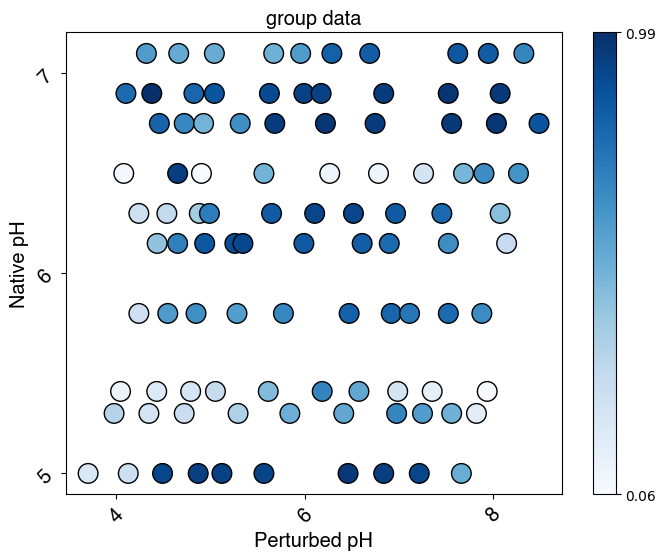

In [91]:
from mgsa.helpers import plot10
plot10(X_NAR_CHL_NEG[:,:,0], 'group data')

### Only pH as X

In [49]:
# from sklearn.linear_model import Lasso
# import numpy as np
# import matplotlib.pyplot as plt

# # Broadcast PERTURBED_PHS across rows
# phs_feature = np.repeat(PERTURBED_PHS[np.newaxis, :], 10, axis=0)  # shape (10, 10)

# # Flatten pH feature to match target shapes
# X_phs_flat = phs_feature.flatten()[:, np.newaxis]  # shape (100, 1)

# # Flatten targets
# y_nar_flat = Y_CHL_NEG[:, :, 0].flatten()  # shape (100,)
# y_nir_flat = Y_CHL_NEG[:, :, 1].flatten()  # shape (100,)

# # LASSO regression with only pH
# ALPHA = 0.01

# clf_nar_phs = Lasso(alpha=ALPHA)
# clf_nar_phs.fit(X_phs_flat, y_nar_flat)

# clf_nir_phs = Lasso(alpha=ALPHA)
# clf_nir_phs.fit(X_phs_flat, y_nir_flat)

# # Print coefficients and intercepts
# print("NAR (pH only) Coefficient:", clf_nar_phs.coef_)
# print("NAR (pH only) Intercept:", clf_nar_phs.intercept_)

# print("NIR (pH only) Coefficient:", clf_nir_phs.coef_)
# print("NIR (pH only) Intercept:", clf_nir_phs.intercept_)

# # Predictions
# pred_rA_phs = clf_nar_phs.predict(X_phs_flat)
# pred_rI_phs = clf_nir_phs.predict(X_phs_flat)

# r2_nar = r2_score(y_nar_flat, pred_rA_phs)
# r2_nir = r2_score(y_nir_flat, pred_rI_phs)

# # Plotting NAR
# nar_scale = 2
# x = np.linspace(0, nar_scale, 10)
# y = np.linspace(0, nar_scale, 10)
# plt.scatter(y_nar_flat, pred_rA_phs, color='Black', alpha=0.5)
# plt.plot(x, y, color='Black', alpha=0.5)
# plt.xlabel('$r_A$ Observed')
# plt.ylabel('$r_A$ Predicted')
# plt.text(0.05, 1.8, f'$R^2$ = {r2_nar:.3f}', fontsize=12, color='black')
# plt.xlim(0, nar_scale)
# plt.ylim(0, nar_scale)
# plt.title('CHL - LASSO prediction $r_A$ (pH only)')
# plt.show()

# # Plotting NIR
# nir_scale = 20
# # x = np.linspace(0, nir_scale, 10)
# y = np.linspace(0, nir_scale, 10)
# plt.scatter(y_nir_flat, pred_rI_phs, color='Black', alpha=0.5)
# plt.plot(x, y, color='Black', alpha=0.5)
# plt.xlabel('$r_I$ Observed')
# plt.ylabel('$r_I$ Predicted')
# plt.text(3, 18, f'$R^2$ = {r2_nir:.3f}', fontsize=12, color='black')
# plt.xlim(0, nir_scale)
# plt.ylim(0, nir_scale)
# plt.title('CHL - LASSO prediction $r_I$ (pH only)')
# plt.show()


### Try with predicting 'model 2' parameters. 

CHL+ T9 to predict rA and CHL- T9 to predict gamma. 

In [5]:
# r_chl_pos = pd.read_csv('../out/metabolic_parameters/r_model2_chl_pos.tsv', sep = '\t', header = None).values
# r_chl_neg = pd.read_csv('../out/metabolic_parameters/r_model2_chl_neg.tsv', sep = '\t', header = None).values

r_chl_pos = pd.read_csv('../out/metabolic_parameters/r_chl.tsv', sep = '\t', header = None).values
# r_chl_pos = pd.read_csv('../out/metabolic_parameters/rA_model1_chl_pos.tsv', sep = '\t', header = None).values
# r_chl_neg = pd.read_csv('../out/metabolic_parameters/rA_model1_chl_neg.tsv', sep = '\t', header = None).values

Y_CHL_POS = r_chl_pos
# Y_CHL_NEG = r_chl_neg

NAR Coefficients: [ 2.33452765 -0.         -0.92732816  0.08351359  0.          2.50007464
  4.36846358 -1.82244647]
NAR Intercept: 0.5538983785006641
NAR Coefficients: [ 1.31042472 -0.         -0.          0.1629603  -0.          4.58633867
  2.9600845  -1.13254808  0.10985978]
NAR Intercept: 0.003013662083289792


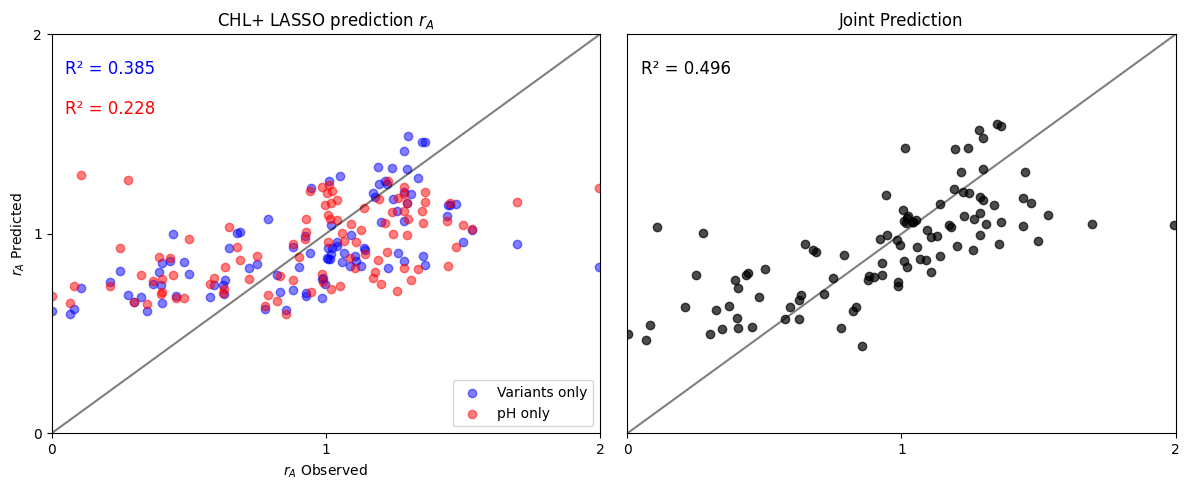

In [63]:
X_nar_flat = X_NAR_CHL_POS.reshape(-1, X_NAR_CHL_POS.shape[2])  # shape: (n_samples * 10, n_features)
y_nar_flat = Y_CHL_POS.flatten()                        # shape: (n_samples * 10,)

ALPHA = 0.0005

clf_nar = Lasso(alpha=ALPHA)
clf_nar.fit(X_nar_flat, y_nar_flat)

print("NAR Coefficients:", clf_nar.coef_)
print("NAR Intercept:", clf_nar.intercept_)

pred_rA = clf_nar.predict(X_nar_flat)
obs_rA = y_nar_flat

r2_nar = r2_score(y_nar_flat, pred_rA)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First plot (left) - Blue and red dots together
nar_scale = 10
x = np.linspace(0,nar_scale,10)
y = np.linspace(0,nar_scale,10)

# Plot blue dots (original)
ax1.scatter(obs_rA, pred_rA, color='blue', alpha=0.5, label='Variants only')

# Plot red dots (pH only)
X_phs_flat = pH_matrix.flatten()[:, np.newaxis]  # shape (100, 1)
y_nar_flat = Y_CHL_POS.flatten()  # shape (100,)
clf_nar_phs = Lasso(alpha=ALPHA)
clf_nar_phs.fit(X_phs_flat, y_nar_flat)
pred_rA_phs = clf_nar_phs.predict(X_phs_flat)
r2_nar_phs = r2_score(y_nar_flat, pred_rA_phs)
ax1.scatter(y_nar_flat, pred_rA_phs, color='red', alpha=0.5, label='pH only')

# Add diagonal line and annotations
ax1.plot(x, y, color='black', alpha=0.5)
ax1.text(0.05, 1.8, f'R² = {r2_nar:.3f}', fontsize=12, color='blue')
ax1.text(0.05, 1.6, f'R² = {r2_nar_phs:.3f}', fontsize=12, color='red')
ax1.set_xlabel('$r_A$ Observed')
ax1.set_ylabel('$r_A$ Predicted')
ax1.set_xticks([0, 1, 2])
ax1.set_yticks([0, 1, 2])
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)
ax1.set_title('CHL+ LASSO prediction $r_A$')
ax1.legend()

# Second plot (right) - Black dots
# Both pH AND variants
phs_feature = pH_matrix[:, :, np.newaxis]  # shape (10, 10, 1)
X_NAR_CHL_POS_aug = np.concatenate((X_NAR_CHL_POS, phs_feature), axis=2)  # shape (10, 10, 5)
X_nar_flat = X_NAR_CHL_POS_aug.reshape(-1, 9)
y_nar_flat = Y_CHL_POS.flatten()

clf_nar = Lasso(alpha=ALPHA)
clf_nar.fit(X_nar_flat, y_nar_flat)

print("NAR Coefficients:", clf_nar.coef_)
print("NAR Intercept:", clf_nar.intercept_)

pred_rA = clf_nar.predict(X_nar_flat)
obs_rA = y_nar_flat

r2_nar = r2_score(y_nar_flat, pred_rA)

# Plot black dots on the second subplot
ax2.scatter(obs_rA, pred_rA, color='black', alpha=0.7)
ax2.plot(x, y, color='black', alpha=0.5)  # Add diagonal line for consistency
ax2.text(0.05, 1.8, f'R² = {r2_nar:.3f}', fontsize=12, color='black')
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 2)
ax2.set_xticks([0, 1, 2])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_title('Joint Prediction')

# Remove boundaries between plots for seamless appearance
plt.tight_layout()
plt.subplots_adjust(wspace=0.05)  # Reduce space between subplots

plt.show()

### Try again but on the left and right half planes seperately

### Another split, but this time, using our information split exactly. 

NAR Positive Region Coefficients: [-0.29959006  0.          0.         -0.          0.         -1.90982974
  1.51037126  0.        ]
NAR Positive Region Intercept: 1.1713668857204893
NAR Negative Region Coefficients: [ 0.         -0.          0.          0.          0.         -0.
  0.         -0.00072443]
NAR Negative Region Intercept: 0.9358518003340723


NameError: name 'X_NAR_TOTAL' is not defined

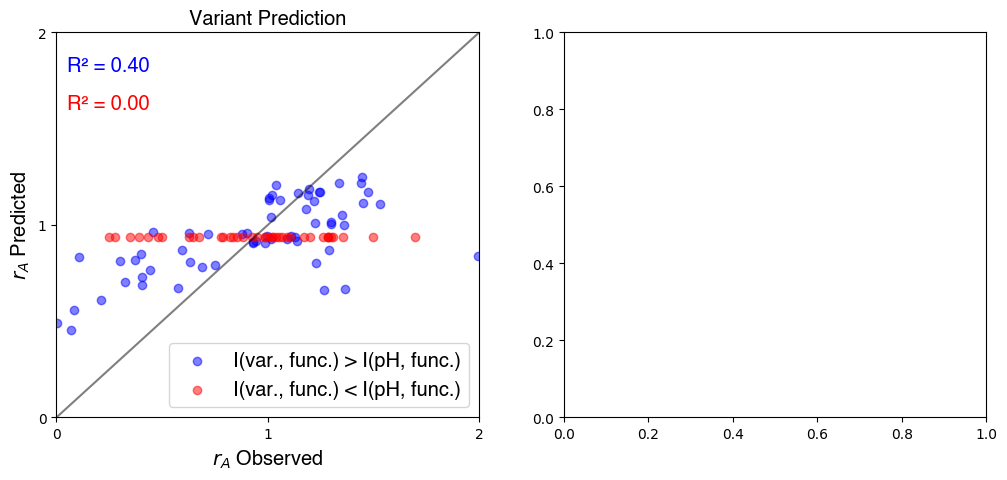

In [12]:
X_nar_flat = X_NAR_CHL_POS.reshape(-1, X_NAR_CHL_POS.shape[2])  # shape: (n_samples * 10, n_features)
y_nar_flat = Y_CHL_POS.flatten()                        # shape: (n_samples * 10,)

ALPHA = 0.005

M = pd.read_csv('../out/info_ratio.tsv', sep = '\t', header = None).values

# Create masks based on the sign of M
positive_mask = M > 0
negative_mask = M <= 0

# Get indices for positive and negative regions
positive_indices = np.where(positive_mask)
negative_indices = np.where(negative_mask)

# Extract positive region data
X_NAR_CHL_POS_positive = X_NAR_CHL_POS[positive_indices[0], positive_indices[1], :]  # shape: (n_positive, 10)
Y_CHL_POS_positive = Y_CHL_POS[positive_indices[0], positive_indices[1]]  # shape: (n_positive,)

# Extract negative region data
X_NAR_CHL_POS_negative = X_NAR_CHL_POS[negative_indices[0], negative_indices[1], :]  # shape: (n_negative, 10)
Y_CHL_POS_negative = Y_CHL_POS[negative_indices[0], negative_indices[1]]  # shape: (n_negative,)

# Fit models for positive and negative regions
clf_nar_positive = Lasso(alpha=ALPHA)
clf_nar_positive.fit(X_NAR_CHL_POS_positive, Y_CHL_POS_positive)

clf_nar_negative = Lasso(alpha=ALPHA) 
clf_nar_negative.fit(X_NAR_CHL_POS_negative, Y_CHL_POS_negative)

print("NAR Positive Region Coefficients:", clf_nar_positive.coef_)
print("NAR Positive Region Intercept:", clf_nar_positive.intercept_)
print("NAR Negative Region Coefficients:", clf_nar_negative.coef_)
print("NAR Negative Region Intercept:", clf_nar_negative.intercept_)

pred_rA_positive = clf_nar_positive.predict(X_NAR_CHL_POS_positive)
pred_rA_negative = clf_nar_negative.predict(X_NAR_CHL_POS_negative)
obs_rA_positive = Y_CHL_POS_positive
obs_rA_negative = Y_CHL_POS_negative

r2_nar_positive = r2_score(Y_CHL_POS_positive, pred_rA_positive)
r2_nar_negative = r2_score(Y_CHL_POS_negative, pred_rA_negative)

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# First plot (left) - Blue and red dots together
nar_scale = 10
x = np.linspace(0,nar_scale,10)
y = np.linspace(0,nar_scale,10)

# Plot blue dots (positive region)
ax1.scatter(obs_rA_positive, pred_rA_positive, color='blue', alpha=0.5, label='I(var., func.) > I(pH, func.)')

# Plot red dots (negative region)
ax1.scatter(obs_rA_negative, pred_rA_negative, color='red', alpha=0.5, label='I(var., func.) < I(pH, func.)')

# Add diagonal line and annotations
ax1.plot(x, y, color='black', alpha=0.5)
ax1.text(0.05, 1.8, f'R² = {r2_nar_positive:.2f}', color='blue', fontsize = 'x-large', fontname = 'Helvetica')
ax1.text(0.05, 1.6, f'R² = {r2_nar_negative:.2f}', color='red', fontsize = 'x-large', fontname = 'Helvetica')
ax1.set_xlabel('$r_A$ Observed', fontsize = 'x-large', fontname = 'Helvetica')
ax1.set_ylabel('$r_A$ Predicted', fontsize = 'x-large', fontname = 'Helvetica')
ax1.set_xticks([0, 1, 2])
ax1.set_yticks([0, 1, 2])
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)
ax1.set_title('Variant Prediction', fontsize = 'x-large', fontname = 'Helvetica')
ax1.legend(prop={'family': 'Helvetica', 'size': 'x-large'})

# Second plot (right) - Black dots (combined)
# clf_nar = Lasso(alpha=ALPHA)
# clf_nar.fit(X_nar_flat, y_nar_flat)

# print("NAR Coefficients:", clf_nar.coef_)
# print("NAR Intercept:", clf_nar.intercept_)

# pred_rA = clf_nar.predict(X_nar_flat)
# obs_rA = y_nar_flat

# r2_nar = r2_score(y_nar_flat, pred_rA)

# # Plot black dots on the second subplot
# ax2.scatter(obs_rA, pred_rA, color='black', alpha=0.7)
# ax2.plot(x, y, color='black', alpha=0.5)  # Add diagonal line for consistency
# ax2.text(0.05, 1.8, f'R² = {r2_nar:.2f}', fontsize=12, color='black')
# ax2.set_xlim(0, 2)
# ax2.set_ylim(0, 2)
# ax2.set_xticks([0, 1, 2])
# ax2.set_yticklabels([])
# ax2.set_yticks([])
# ax2.set_title('Complete Prediction', fontsize = 'x-large', fontname = 'Helvetica')


phs_feature = pH_matrix[:, :, np.newaxis]  # shape (10, 10, 1)
X_nar_sum = X_NAR_TOTAL[:,:, np.newaxis]
X_NAR_CHL_POS_aug = np.concatenate((X_NAR_CHL_POS, X_nar_sum, phs_feature), axis=2)  # shape (10, 10, 5)
X_nar_flat = X_NAR_CHL_POS_aug.reshape(-1, 10)
y_nar_flat = Y_CHL_POS.flatten()

clf_nar = Lasso(alpha=ALPHA)
clf_nar.fit(X_nar_flat, y_nar_flat)

print("NAR Coefficients:", clf_nar.coef_)
print("NAR Intercept:", clf_nar.intercept_)

pred_rA = clf_nar.predict(X_nar_flat)
obs_rA = y_nar_flat

r2_nar = r2_score(y_nar_flat, pred_rA)

# Plot black dots on the second subplot
ax2.scatter(obs_rA, pred_rA, color='black', alpha=0.7)
ax2.plot(x, y, color='black', alpha=0.5)  # Add diagonal line for consistency
ax2.text(0.05, 1.8, f'R² = {r2_nar:.2f}', color='black', fontsize = 'x-large', fontname = 'Helvetica')
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 2)
ax2.set_xticks([0, 1, 2])
ax2.set_yticklabels([])
ax2.set_yticks([])
ax2.set_title('Joint Prediction', fontsize = 'x-large', fontname = 'Helvetica')

# Remove boundaries between plots for seamless appearance
plt.tight_layout()
plt.subplots_adjust(wspace=0.05)  # Reduce space between subplots

plt.show()

NAR Positive Region Coefficients: [-0.29959006  0.          0.         -0.          0.         -1.90982974
  1.51037126  0.        ]
NAR Positive Region Intercept: 1.1713668857204893
NAR Negative Region Coefficients: [ 0.         -0.          0.          0.          0.         -0.
  0.         -0.00072443]
NAR Negative Region Intercept: 0.9358518003340723


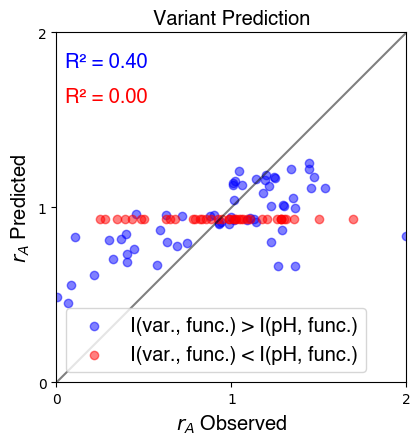

In [14]:
X_nar_flat = X_NAR_CHL_POS.reshape(-1, X_NAR_CHL_POS.shape[2])  # shape: (n_samples * 10, n_features)
y_nar_flat = Y_CHL_POS.flatten()                        # shape: (n_samples * 10,)

ALPHA = 0.005

M = pd.read_csv('../out/info_ratio.tsv', sep = '\t', header = None).values

# Create masks based on the sign of M
positive_mask = M > 0
negative_mask = M <= 0

# Get indices for positive and negative regions
positive_indices = np.where(positive_mask)
negative_indices = np.where(negative_mask)

# Extract positive region data
X_NAR_CHL_POS_positive = X_NAR_CHL_POS[positive_indices[0], positive_indices[1], :]  # shape: (n_positive, 10)
Y_CHL_POS_positive = Y_CHL_POS[positive_indices[0], positive_indices[1]]  # shape: (n_positive,)

# Extract negative region data
X_NAR_CHL_POS_negative = X_NAR_CHL_POS[negative_indices[0], negative_indices[1], :]  # shape: (n_negative, 10)
Y_CHL_POS_negative = Y_CHL_POS[negative_indices[0], negative_indices[1]]  # shape: (n_negative,)

# Fit models for positive and negative regions
clf_nar_positive = Lasso(alpha=ALPHA)
clf_nar_positive.fit(X_NAR_CHL_POS_positive, Y_CHL_POS_positive)

clf_nar_negative = Lasso(alpha=ALPHA) 
clf_nar_negative.fit(X_NAR_CHL_POS_negative, Y_CHL_POS_negative)

print("NAR Positive Region Coefficients:", clf_nar_positive.coef_)
print("NAR Positive Region Intercept:", clf_nar_positive.intercept_)
print("NAR Negative Region Coefficients:", clf_nar_negative.coef_)
print("NAR Negative Region Intercept:", clf_nar_negative.intercept_)

pred_rA_positive = clf_nar_positive.predict(X_NAR_CHL_POS_positive)
pred_rA_negative = clf_nar_negative.predict(X_NAR_CHL_POS_negative)
obs_rA_positive = Y_CHL_POS_positive
obs_rA_negative = Y_CHL_POS_negative

r2_nar_positive = r2_score(Y_CHL_POS_positive, pred_rA_positive)
r2_nar_negative = r2_score(Y_CHL_POS_negative, pred_rA_negative)


# Create a wide figure (10 inches wide, 5 tall)
fig = plt.figure(figsize=(10, 5))

# Add a square axes centered in the figure
# [left, bottom, width, height] in figure fraction coordinates
# We want a square (5/10 = 0.5 width), centered horizontally
ax1 = fig.add_axes([0.25, 0.15, 0.5, 0.7])  # left=0.25, width=0.5 → centered

# Now plot your data on ax1 (same as before)
nar_scale = 10
x = np.linspace(0, nar_scale, 10)
y = np.linspace(0, nar_scale, 10)

ax1.scatter(obs_rA_positive, pred_rA_positive, color='blue', alpha=0.5, label='I(var., func.) > I(pH, func.)')
ax1.scatter(obs_rA_negative, pred_rA_negative, color='red', alpha=0.5, label='I(var., func.) < I(pH, func.)')

ax1.plot(x, y, color='black', alpha=0.5)
ax1.text(0.05, 1.8, f'R² = {r2_nar_positive:.2f}', color='blue', fontsize='x-large', fontname='Helvetica')
ax1.text(0.05, 1.6, f'R² = {r2_nar_negative:.2f}', color='red', fontsize='x-large', fontname='Helvetica')

ax1.set_xlabel('$r_A$ Observed', fontsize='x-large', fontname='Helvetica')
ax1.set_ylabel('$r_A$ Predicted', fontsize='x-large', fontname='Helvetica')
ax1.set_xticks([0, 1, 2])
ax1.set_yticks([0, 1, 2])
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)
ax1.set_aspect('equal', adjustable='box')  # Ensures square aspect ratio
ax1.set_title('Variant Prediction', fontsize='x-large', fontname='Helvetica')
ax1.legend(prop={'family': 'Helvetica', 'size': 'x-large'})

plt.show()

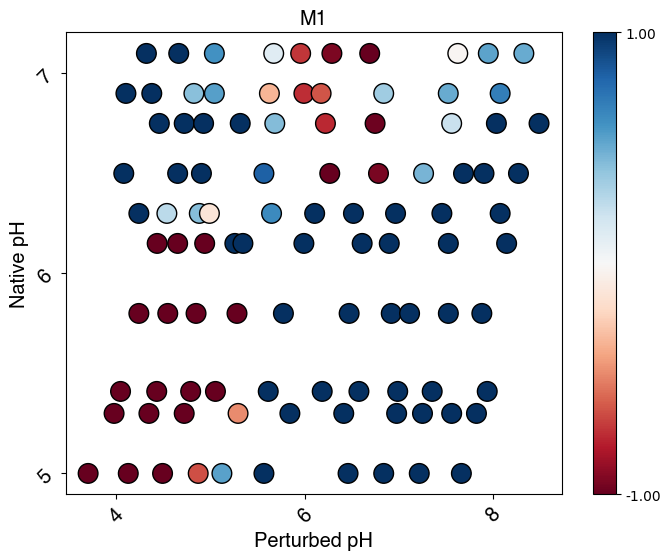

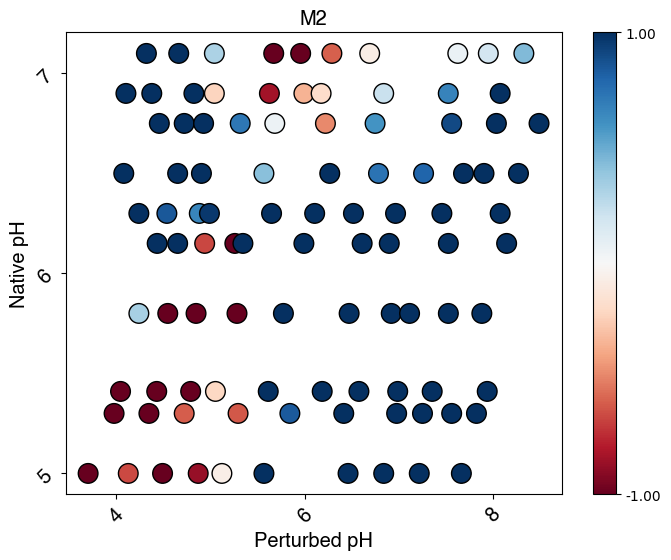

In [16]:
from mgsa.helpers import plot10
M1 = pd.read_csv('../out/info_ratio.tsv', header = None, sep = '\t').values
M2 = pd.read_csv('../out/info_ratio_2.tsv', header = None, sep = '\t').values
plot10(M1, 'M1', vmin = -1, vmax = 1, cmap = 'RdBu')
plot10(M2, 'M2', vmin = -1, vmax = 1, cmap = 'RdBu')

In [48]:
# X_nar_flat = X_NAR_CHL_NEG.reshape(-1, X_NAR_CHL_NEG.shape[2])  # shape: (n_samples * 10, n_features)
# y_nar_flat = Y_CHL_NEG.flatten()                        # shape: (n_samples * 10,)

# ALPHA = 0.001

# clf_nar = Lasso(alpha=ALPHA)
# clf_nar.fit(X_nar_flat, y_nar_flat)

# print("NAR Coefficients:", clf_nar.coef_)
# print("NAR Intercept:", clf_nar.intercept_)

# pred_rA = clf_nar.predict(X_nar_flat)
# obs_rA = y_nar_flat

# r2_nar = r2_score(y_nar_flat, pred_rA)

# # Create a figure with two subplots side by side
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# # First plot (left) - Blue and red dots together
# nar_scale = 2     
# x = np.linspace(0,nar_scale,10)
# y = np.linspace(0,nar_scale,10)

# # Plot blue dots (original)
# ax1.scatter(obs_rA, pred_rA, color='blue', alpha=0.5, label='Variants only')

# # Plot red dots (pH only)
# X_phs_flat = pH_matrix.flatten()[:, np.newaxis]  # shape (100, 1)
# y_nar_flat = Y_CHL_NEG.flatten()  # shape (100,)
# clf_nar_phs = Lasso(alpha=ALPHA)
# clf_nar_phs.fit(X_phs_flat, y_nar_flat)
# pred_rA_phs = clf_nar_phs.predict(X_phs_flat)
# r2_nar_phs = r2_score(y_nar_flat, pred_rA_phs)
# ax1.scatter(y_nar_flat, pred_rA_phs, color='red', alpha=0.5, label='pH only')

# # Add diagonal line and annotations
# ax1.plot(x, y, color='black', alpha=0.5)
# ax1.text(0.05, 1.8, f'R² = {r2_nar:.3f}', fontsize=12, color='blue')
# ax1.text(0.05, 1.6, f'R² = {r2_nar_phs:.3f}', fontsize=12, color='red')
# ax1.set_xlabel('$r_A$ Observed')
# ax1.set_ylabel('$r_A$ Predicted')
# ax1.set_xticks([0, 1, 2])
# ax1.set_yticks([0, 1, 2])
# ax1.set_xlim(0, nar_scale)
# ax1.set_ylim(0, nar_scale)
# ax1.set_title('CHL- LASSO prediction $r_A$')
# ax1.legend()

# # Second plot (right) - Black dots
# # Both pH AND variants
# phs_feature = pH_matrix[:, :, np.newaxis]  # shape (10, 10, 1)
# X_NAR_CHL_NEG_aug = np.concatenate((X_NAR_CHL_NEG, phs_feature), axis=2)  # shape (10, 10, 5)
# X_nar_flat = X_NAR_CHL_NEG_aug.reshape(-1, 9)
# y_nar_flat = Y_CHL_NEG.flatten()

# clf_nar = Lasso(alpha=ALPHA)
# clf_nar.fit(X_nar_flat, y_nar_flat)

# print("NAR Coefficients:", clf_nar.coef_)
# print("NAR Intercept:", clf_nar.intercept_)

# pred_rA = clf_nar.predict(X_nar_flat)
# obs_rA = y_nar_flat

# r2_nar = r2_score(y_nar_flat, pred_rA)

# # Plot black dots on the second subplot
# ax2.scatter(obs_rA, pred_rA, color='black', alpha=0.7)
# ax2.plot(x, y, color='black', alpha=0.5)  # Add diagonal line for consistency
# ax2.text(0.05, 1.8, f'R² = {r2_nar:.3f}', fontsize=12, color='black')
# ax2.set_xlim(0, nar_scale)
# ax2.set_ylim(0, nar_scale)
# ax2.set_xticks([0, 1, 2])
# ax2.set_yticklabels([])
# ax2.set_yticks([])
# ax2.set_title('Joint Prediction')

# # Remove boundaries between plots for seamless appearance
# plt.tight_layout()
# plt.subplots_adjust(wspace=0.05)  # Reduce space between subplots

# plt.show()

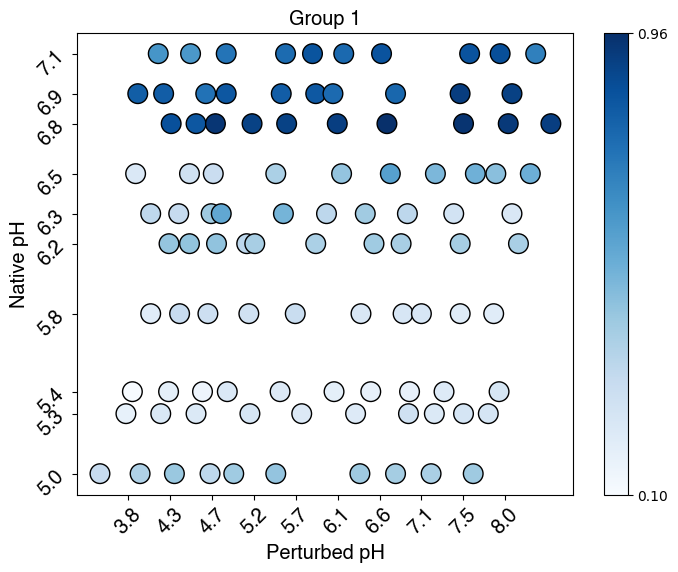

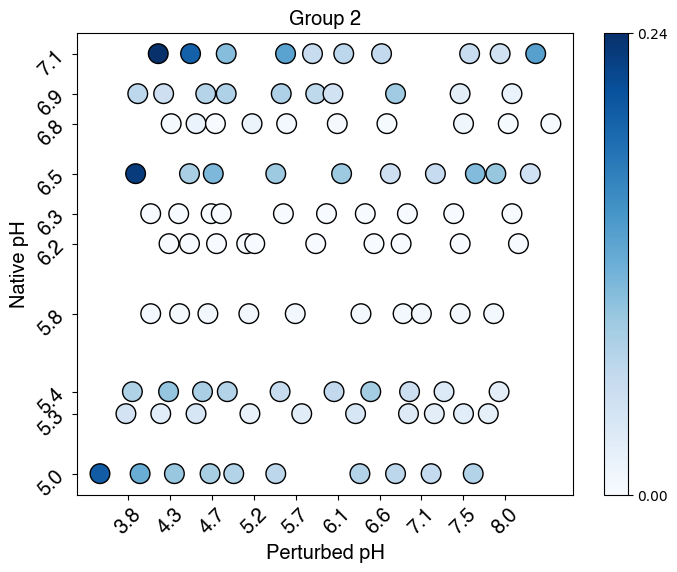

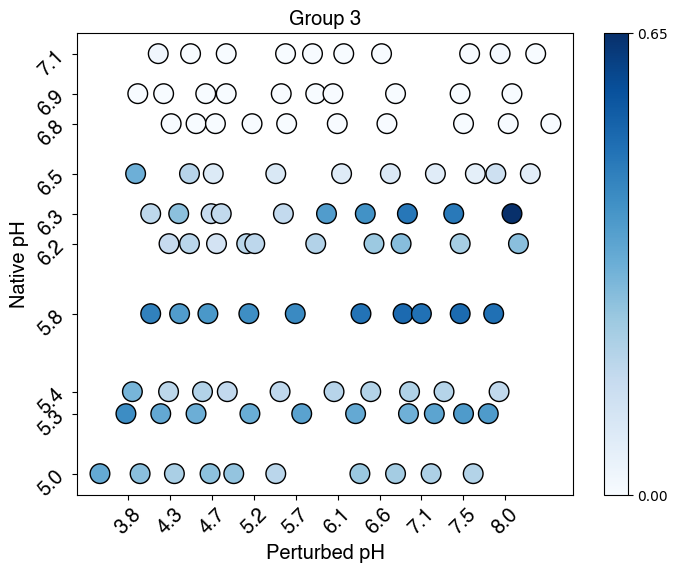

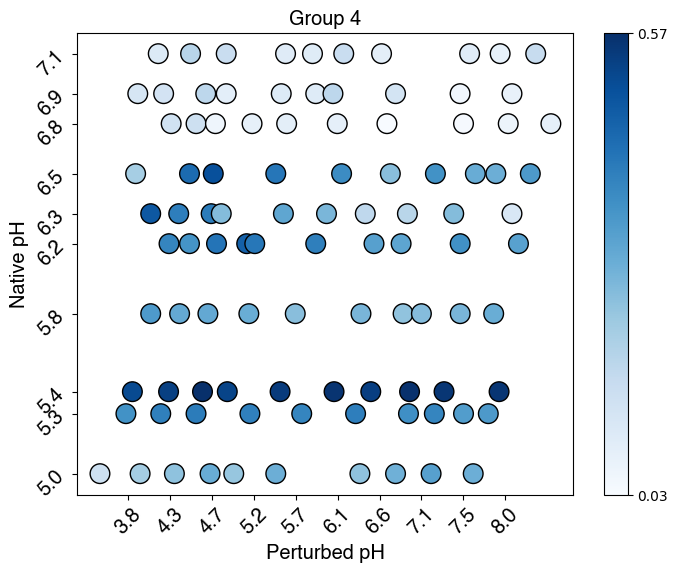

In [ ]:
plot10(X_NAR_CHL_POS[:,:,0], 'Group 1')
plot10(X_NAR_CHL_POS[:,:,1], 'Group 2')
plot10(X_NAR_CHL_POS[:,:,2], 'Group 3')
plot10(X_NAR_CHL_POS[:,:,3], 'Group 4')

### Things to try (notes)

- Try without, with, and only pH (when is pH necessary and when isn't it)
- Try without normalizing abundance (total abundance not normalized abundance)
- Try with different groups (why is group 2 useless here?)
- Try with CHL-/CHL+ folds doing the prediction?

#### Why does CHL+ do bad? 

Because CHL+ variant distributions have no perturbed dependence

#### Why does nitrite do bad? 

The issue is, for ~most of the samples, particularly if we ignore regime III, the nitrite dynamics are a flat line at (or near) zero.

Why are they like this? I think because most of the nitrite stays in the cell as reduction is coupled to nitrate reduction. What does the model do? It solves this by fitting a very high r_I, eliminating the nitrite quickly to explain why you don't see it. But, in principle, there is not good reason to think these are the correct values of r_I.

So not only are the values wrong, but the LASSO is doing a pretty bad job predicting these 'r_I's that the model fits.

Solution: Just do a variants project focused on narG and nitrate dynamics.
